# Figure 3: Dynamics of decision parameters across action costs.

## setup and imports

In [2]:
import fnmatch
import matplotlib.pyplot as plt
import numpy as np
import glob

from sessionlists import (dist60, dist90, dist120, TM20, TM10, TM2, TMrev2, TMrev10, TMrev20)
from utils import *
from plotting import *
from model_functions import *
from initialize_notebook import initialize_notebook

plt.style.use('./Figures/paper.mplstyle')

In [3]:
root, rat_lists, rat_markers, (example_rat, example_session), GENERAL_PLOT_PARAMS = initialize_notebook()
intact_rats, DSlesioned_rats, VSlesioned_rats, sham_rats, all_rats = rat_lists

Found 84 rats in the DATA folder
Listed 59 rats in total, of which 19 are intact (8♀, 11♂), 19 DS lesions, 17 VS lesions and 4 shams.
Example rat is RatM00, example session: RatM00_2021_07_22_16_13_03


In [4]:
sequence = {}

for index, animal in enumerate(all_rats):
    for session in sorted(matchsession(animal, dist60+dist90+dist120 + TM20+TM10+TM2+TMrev2+TMrev10+TMrev20)):
        sequence[animal, session] = get_from_pickle(root, animal[0:6], session, name="sequence.p")

# Figure 3A Schematics of three action cost conditions with increasing platform distances.
# Figure 3D Same with treadmill velocity.

In [11]:
def get_run_speed(example_rat=example_rat, session=example_session, animal_list=[]):

    conds = ["60", "90", "120", "20", "10", "2", "rev10", "rev20"]
    run_speeds = {k: {a: [] for a in conds} for k in animal_list}
    median_run_speeds = {k: {a: [] for a in conds} for k in animal_list}

    for cond, sessionlist in zip(conds, [dist60, dist90, dist120, TM20, TM10, TM2, TMrev10, TMrev20]):
        for animal in animal_list:
            for session in matchsession(animal, sessionlist):
                params = get_from_pickle(root, animal, session, name="params.p")
                for elem in sequence[animal, session]:
                    if get_block(sequence[animal, session][elem][0]) <= 1:
                        if sequence[animal, session][elem][1] == 'run':
                            tm_speed = params['treadmillSpeed'][get_block(sequence[animal, session][elem][0])]
                            run_speeds[animal][cond].append(abs(sequence[animal, session][elem][-1]) - tm_speed)
    for animal in animal_list:
        for cond in conds:
            median_run_speeds[animal][cond] = np.median(run_speeds[animal][cond])

    # for Fig 5
    if example_rat in animal_list:
        pickle.dump([np.median(run_speeds[example_rat][cond]) for cond in conds], open("picklejar/example_rat_run_speeds.p", "wb"))

        # example session
        example_session_run_speeds = []
        params = get_from_pickle(root, example_rat, example_session, name="params.p")
        for elem in sequence[example_rat, example_session]:
            if get_block(sequence[example_rat, example_session][elem][0]) <= 1:
                if sequence[example_rat, example_session][elem][1] == 'run':
                    tm_speed = params['treadmillSpeed'][get_block(sequence[example_rat, example_session][elem][0])]
                    example_session_run_speeds.append(abs(sequence[example_rat, example_session][elem][-1]) - tm_speed)

        return median_run_speeds, np.median(example_session_run_speeds)
    return median_run_speeds, 0

run_speeds, ex_run_speed = get_run_speed(animal_list=intact_rats)
run_speeds_lesion, _ = get_run_speed(animal_list=DSlesioned_rats+VSlesioned_rats)


PLOT_PARAMS = {
    'run_speed': dict(fit=run_speeds, ex_fit=ex_run_speed, yticks=[20, 40, 60, 80, 100, ], ylabel='Run Speed', start='med', end=1),
    'run_speed_lesion': dict(fit=run_speeds_lesion, ex_fit=0, yticks=[20, 40, 60, 80, 100, ], ylabel='Run Speed', start='med', end=1)
}


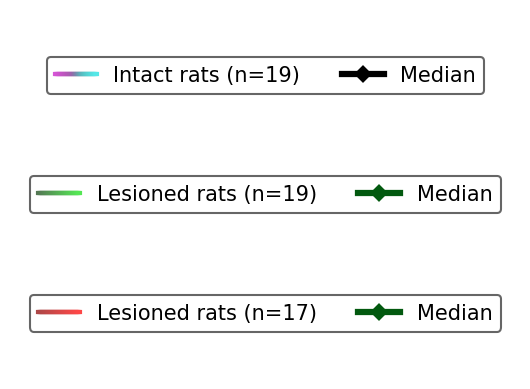

In [10]:
def dummy_legend_lesion(ax=None, DSlesioned_rats=DSlesioned_rats):
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    
    median_lesion = ax.plot([-100, -101], [-100, -101], color='xkcd:deep green', marker='D', markersize=2, linestyle='-', lw=1.5, label=f'Median lesioned rats', zorder=5)

    add_colored_lesion(ax=ax, loc='center', bbox=(.5, .5), ncol=2,
                       handles=[median_lesion], labels=['Median'],
                       text=f'Lesioned rats (n={len(DSlesioned_rats)})')
    ax.axis('off')
    ax.set_xlim(10, 11)
    ax.set_ylim(10, 11)

def dummy_legend_lesion_vs(ax=None, VSlesioned_rats=VSlesioned_rats):
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    
    median_lesion = ax.plot([-100, -101], [-100, -101], color='xkcd:deep green', marker='D', markersize=2, linestyle='-', lw=1.5, label=f'Median lesioned rats', zorder=5)

    add_colored_lesion(ax=ax, loc='center', bbox=(.5, .5), ncol=2, group='VS',
                       handles=[median_lesion], labels=['Median'],
                       text=f'Lesioned rats (n={len(VSlesioned_rats)})')
    ax.axis('off')
    ax.set_xlim(10, 11)
    ax.set_ylim(10, 11)

def dummy_legend_intact(ax=None, intact_rats=intact_rats):
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(5, 5))

    median = ax.plot([-100, -101], [-100, -101], color='k', marker='D', markersize=2, linestyle='-', lw=1.5, label=f'Median', zorder=5)

    ax.axis('off')
    ax.set_xlim(10, 11)
    ax.set_ylim(10, 11)

    add_colored_intact(ax, handles=[median], ncol=2,
                    labels=['Median'], text=f'Intact rats (n={len(intact_rats)})',
                    loc='center', bbox=(.5, .5))


fig, axs = plt.subplots(3, 1, figsize=(cm2inch(3), cm2inch(3)))
dummy_legend_intact(ax=axs[0])
dummy_legend_lesion(ax=axs[1])
dummy_legend_lesion_vs(ax=axs[2])

p_s=0.000, p_i=0.000, obs_slope=15.923, obs_intercept=37.687
p_s=0.000, p_i=0.000, obs_slope=7.547, obs_intercept=54.075
p_s=0.000, p_i=0.000, obs_slope=15.047, obs_intercept=33.897
p_s=0.000, p_i=0.000, obs_slope=6.974, obs_intercept=45.248


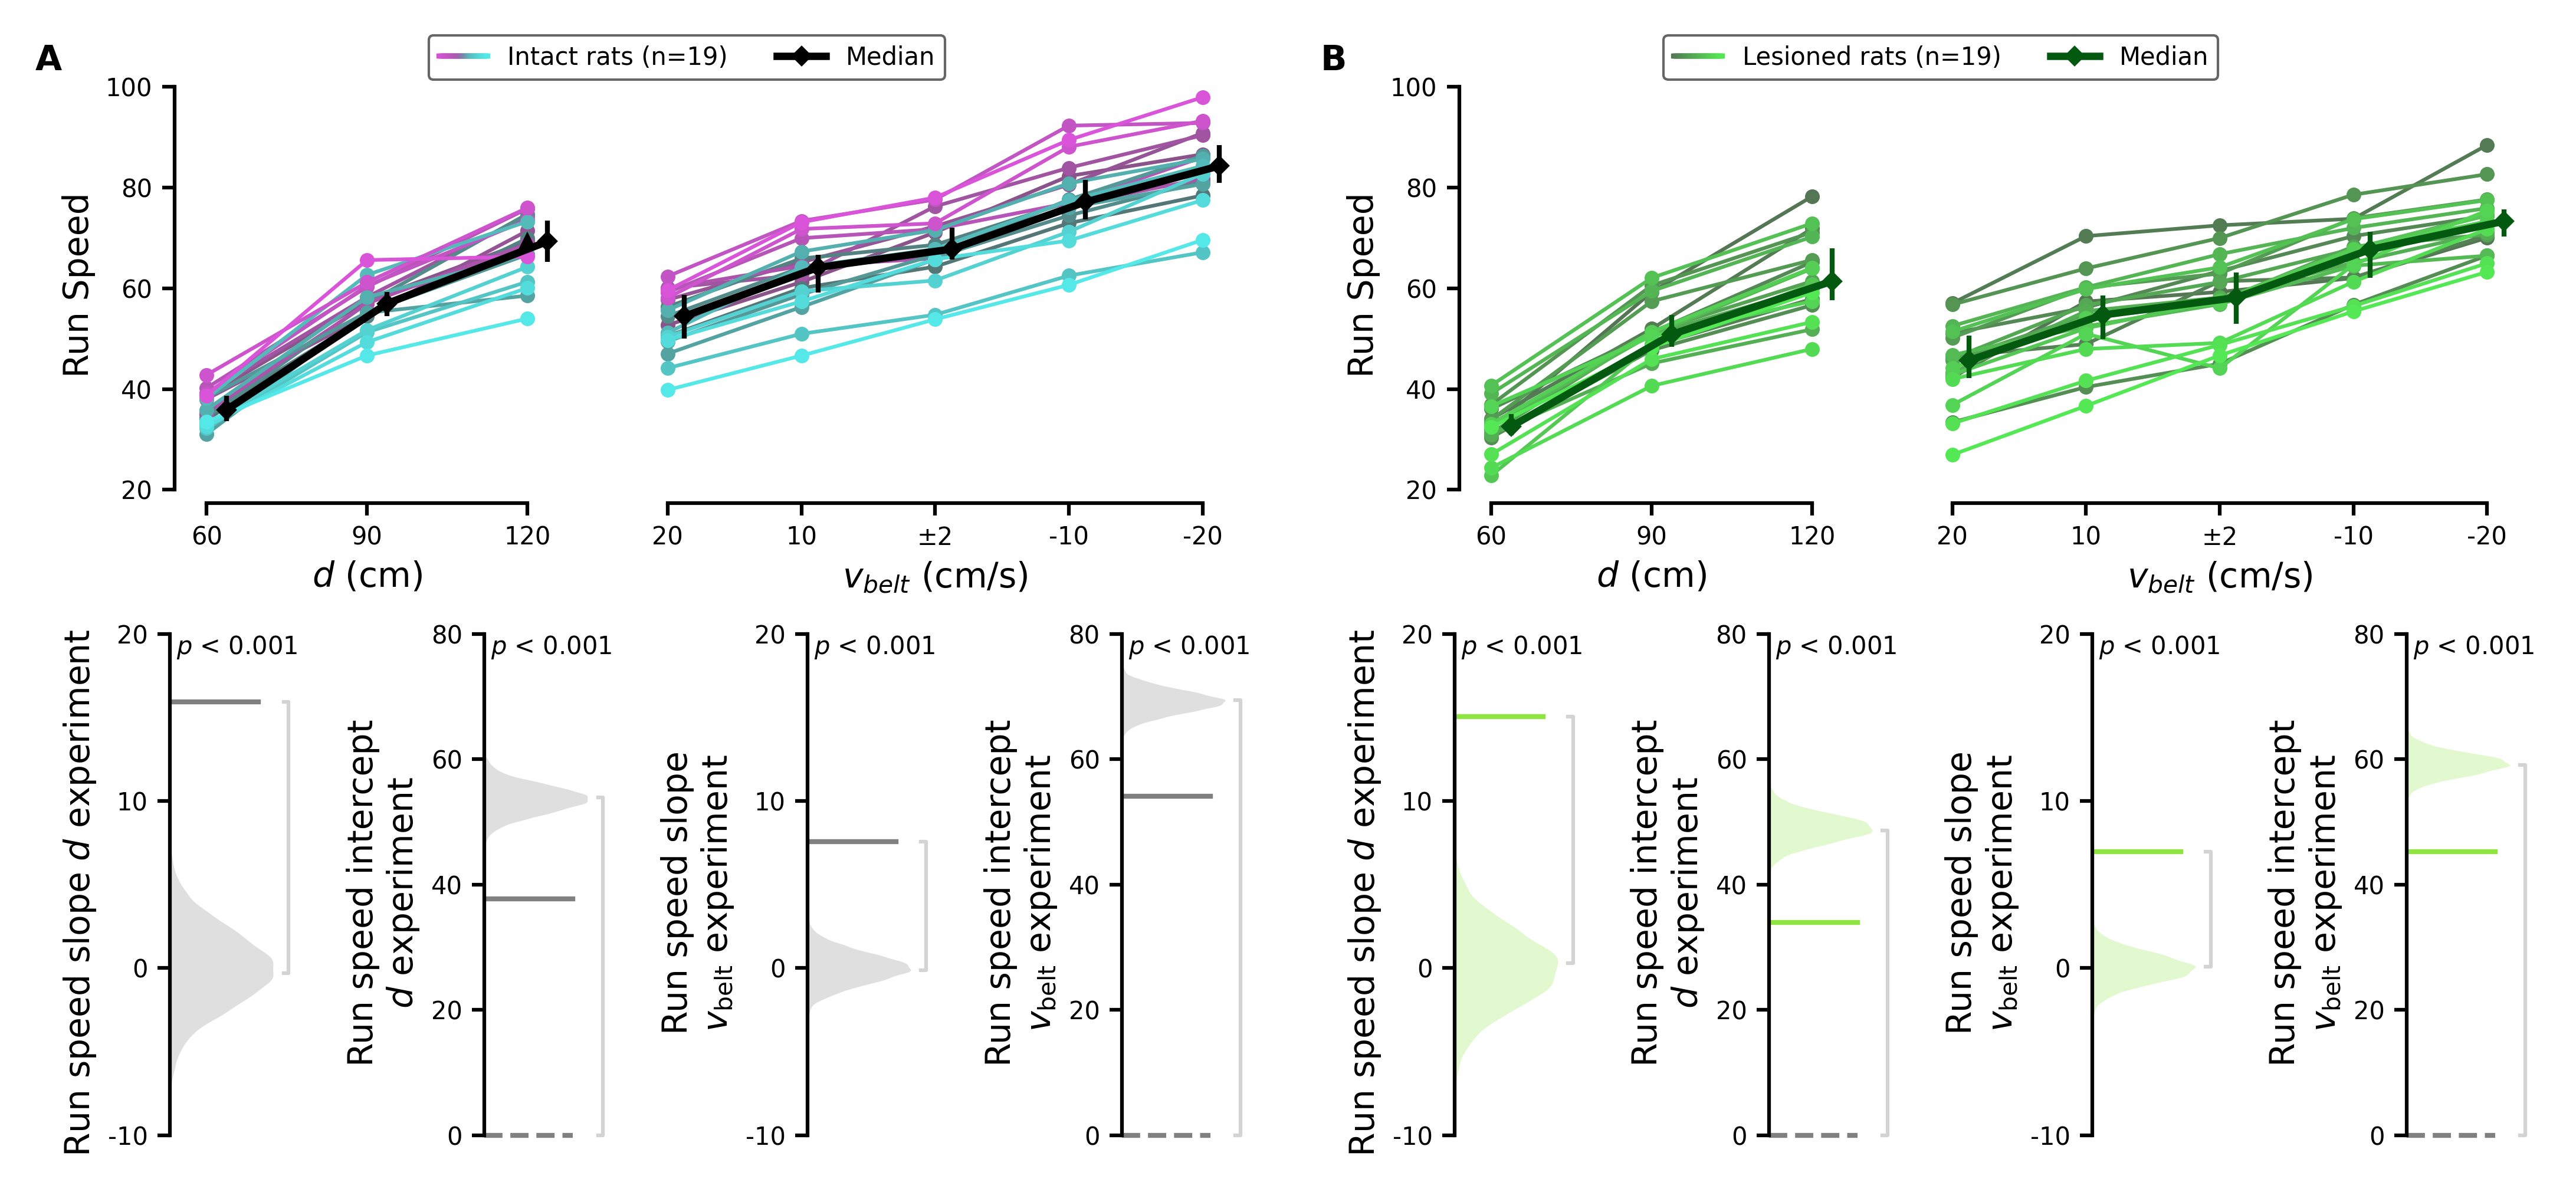

In [ ]:
fig = plt.figure(figsize=(cm2inch(18), cm2inch(8)),
                 constrained_layout=True, facecolor='w', dpi=600)

gs0 = fig.add_gridspec(1, 3, width_ratios=[1, .05, 1])

left = gs0[0].subgridspec(2, 1)
left_row1 = left[0].subgridspec(1, 2, width_ratios=[3, 5])
ax_dist_intact = plt.subplot(left_row1[0])
ax_tm_intact = plt.subplot(left_row1[1])

left_row2 = left[1].subgridspec(1, 4)
ax_slope_dist_intact = plt.subplot(left_row2[0])
ax_intercept_dist_intact = plt.subplot(left_row2[1])
ax_slope_tm_intact = plt.subplot(left_row2[2])
ax_intercept_tm_intact = plt.subplot(left_row2[3])


right = gs0[2].subgridspec(2, 1)
right_row1 = right[0].subgridspec(1, 2, width_ratios=[3, 5])
ax_dist_lesion = plt.subplot(right_row1[0])
ax_tm_lesion = plt.subplot(right_row1[1])

right_row2 = right[1].subgridspec(1, 4)
ax_slope_dist_lesion = plt.subplot(right_row2[0])
ax_intercept_dist_lesion = plt.subplot(right_row2[1])
ax_slope_tm_lesion = plt.subplot(right_row2[2])
ax_intercept_tm_lesion = plt.subplot(right_row2[3])

_ = r'$d$'
__ = r'$v_{\mathrm{belt}}$'

plot_model_parameter(PLOT_PARAMS['run_speed'], rat_markers, dist_or_tm='dist', show_ex=True, ax=ax_dist_intact,
                     animal_list=intact_rats, show_xlabel=True, show_ylabel=True)

plot_model_parameter(PLOT_PARAMS['run_speed'], rat_markers, dist_or_tm='tm', show_ex=False, ax=ax_tm_intact,
                     animal_list=intact_rats, show_xlabel=True, show_ylabel=False, hide_y=True)

regression_permutation(run_speeds, dist_or_tm='dist', animal_list=intact_rats, color='gray',
                       varname_slope=f'Run speed slope {_} experiment',
                        varname_intercept=f'Run speed intercept\n{_} experiment',
                        ax_slope=ax_slope_dist_intact, yticks_slope=[-10, 0, 10, 20],
                        ax_intercept=ax_intercept_dist_intact, y_ticks_intercept=[0, 20, 40, 60, 80])

regression_permutation(run_speeds, dist_or_tm='tm', animal_list=intact_rats, color='gray',
                       varname_slope=f'Run speed slope\n{__} experiment',
                        varname_intercept=f'Run speed intercept\n{__} experiment',
                        ax_slope=ax_slope_tm_intact, yticks_slope=[-10, 0, 10, 20],
                        ax_intercept=ax_intercept_tm_intact, y_ticks_intercept=[0, 20, 40, 60, 80])



plot_model_parameter(PLOT_PARAMS['run_speed_lesion'], rat_markers,dist_or_tm='dist', show_ex=True, ax=ax_dist_lesion,
                     animal_list=DSlesioned_rats, show_xlabel=True, show_ylabel=True, median_color='xkcd:deep green')

plot_model_parameter(PLOT_PARAMS['run_speed_lesion'], rat_markers,dist_or_tm='tm', show_ex=False, ax=ax_tm_lesion,
                     animal_list=DSlesioned_rats, show_xlabel=True, show_ylabel=False, median_color='xkcd:deep green', hide_y=True)

regression_permutation(run_speeds_lesion, dist_or_tm='dist', animal_list=DSlesioned_rats, color='xkcd:kiwi green',
                        varname_slope=f'Run speed slope {_} experiment',
                        varname_intercept=f'Run speed intercept\n{_} experiment',
                        ax_slope=ax_slope_dist_lesion, yticks_slope=[-10, 0, 10, 20],
                        ax_intercept=ax_intercept_dist_lesion, y_ticks_intercept=[0, 20, 40, 60, 80])

regression_permutation(run_speeds_lesion, dist_or_tm='tm', animal_list=DSlesioned_rats, color='xkcd:kiwi green',
                       varname_slope=f'Run speed slope\n{__} experiment',
                        varname_intercept=f'Run speed intercept\n{__} experiment',
                        ax_slope=ax_slope_tm_lesion, yticks_slope=[-10, 0, 10, 20],
                        ax_intercept=ax_intercept_tm_lesion, y_ticks_intercept=[0, 20, 40, 60, 80])

legend_intact = fig.add_axes([.25, .99, .01, .01])
legend_lesion = fig.add_axes([.75, .99, .01, .01])
dummy_legend_intact(ax=legend_intact)
dummy_legend_lesion(ax=legend_lesion)

add_all_letters([ax_dist_intact, ax_dist_lesion], ["A", "B"])

plt.savefig("./Figures_paper/Figure_SXXXX.pdf", facecolor='w', 
        edgecolor='none', bbox_inches='tight', format="pdf", dpi=600)
plt.savefig("./Figures_paper/Figure_SXXXX.svg", facecolor='w', 
        edgecolor='none', bbox_inches='tight', format="svg", dpi=600)

p_s=0.000, p_i=0.000, obs_slope=15.923, obs_intercept=37.687
p_s=0.000, p_i=0.000, obs_slope=7.547, obs_intercept=54.075
p_s=0.000, p_i=0.000, obs_slope=15.047, obs_intercept=33.897
p_s=0.000, p_i=0.000, obs_slope=6.974, obs_intercept=45.248
p_s=0.000, p_i=0.000, obs_slope=13.096, obs_intercept=32.992
p_s=0.000, p_i=0.000, obs_slope=7.531, obs_intercept=42.703


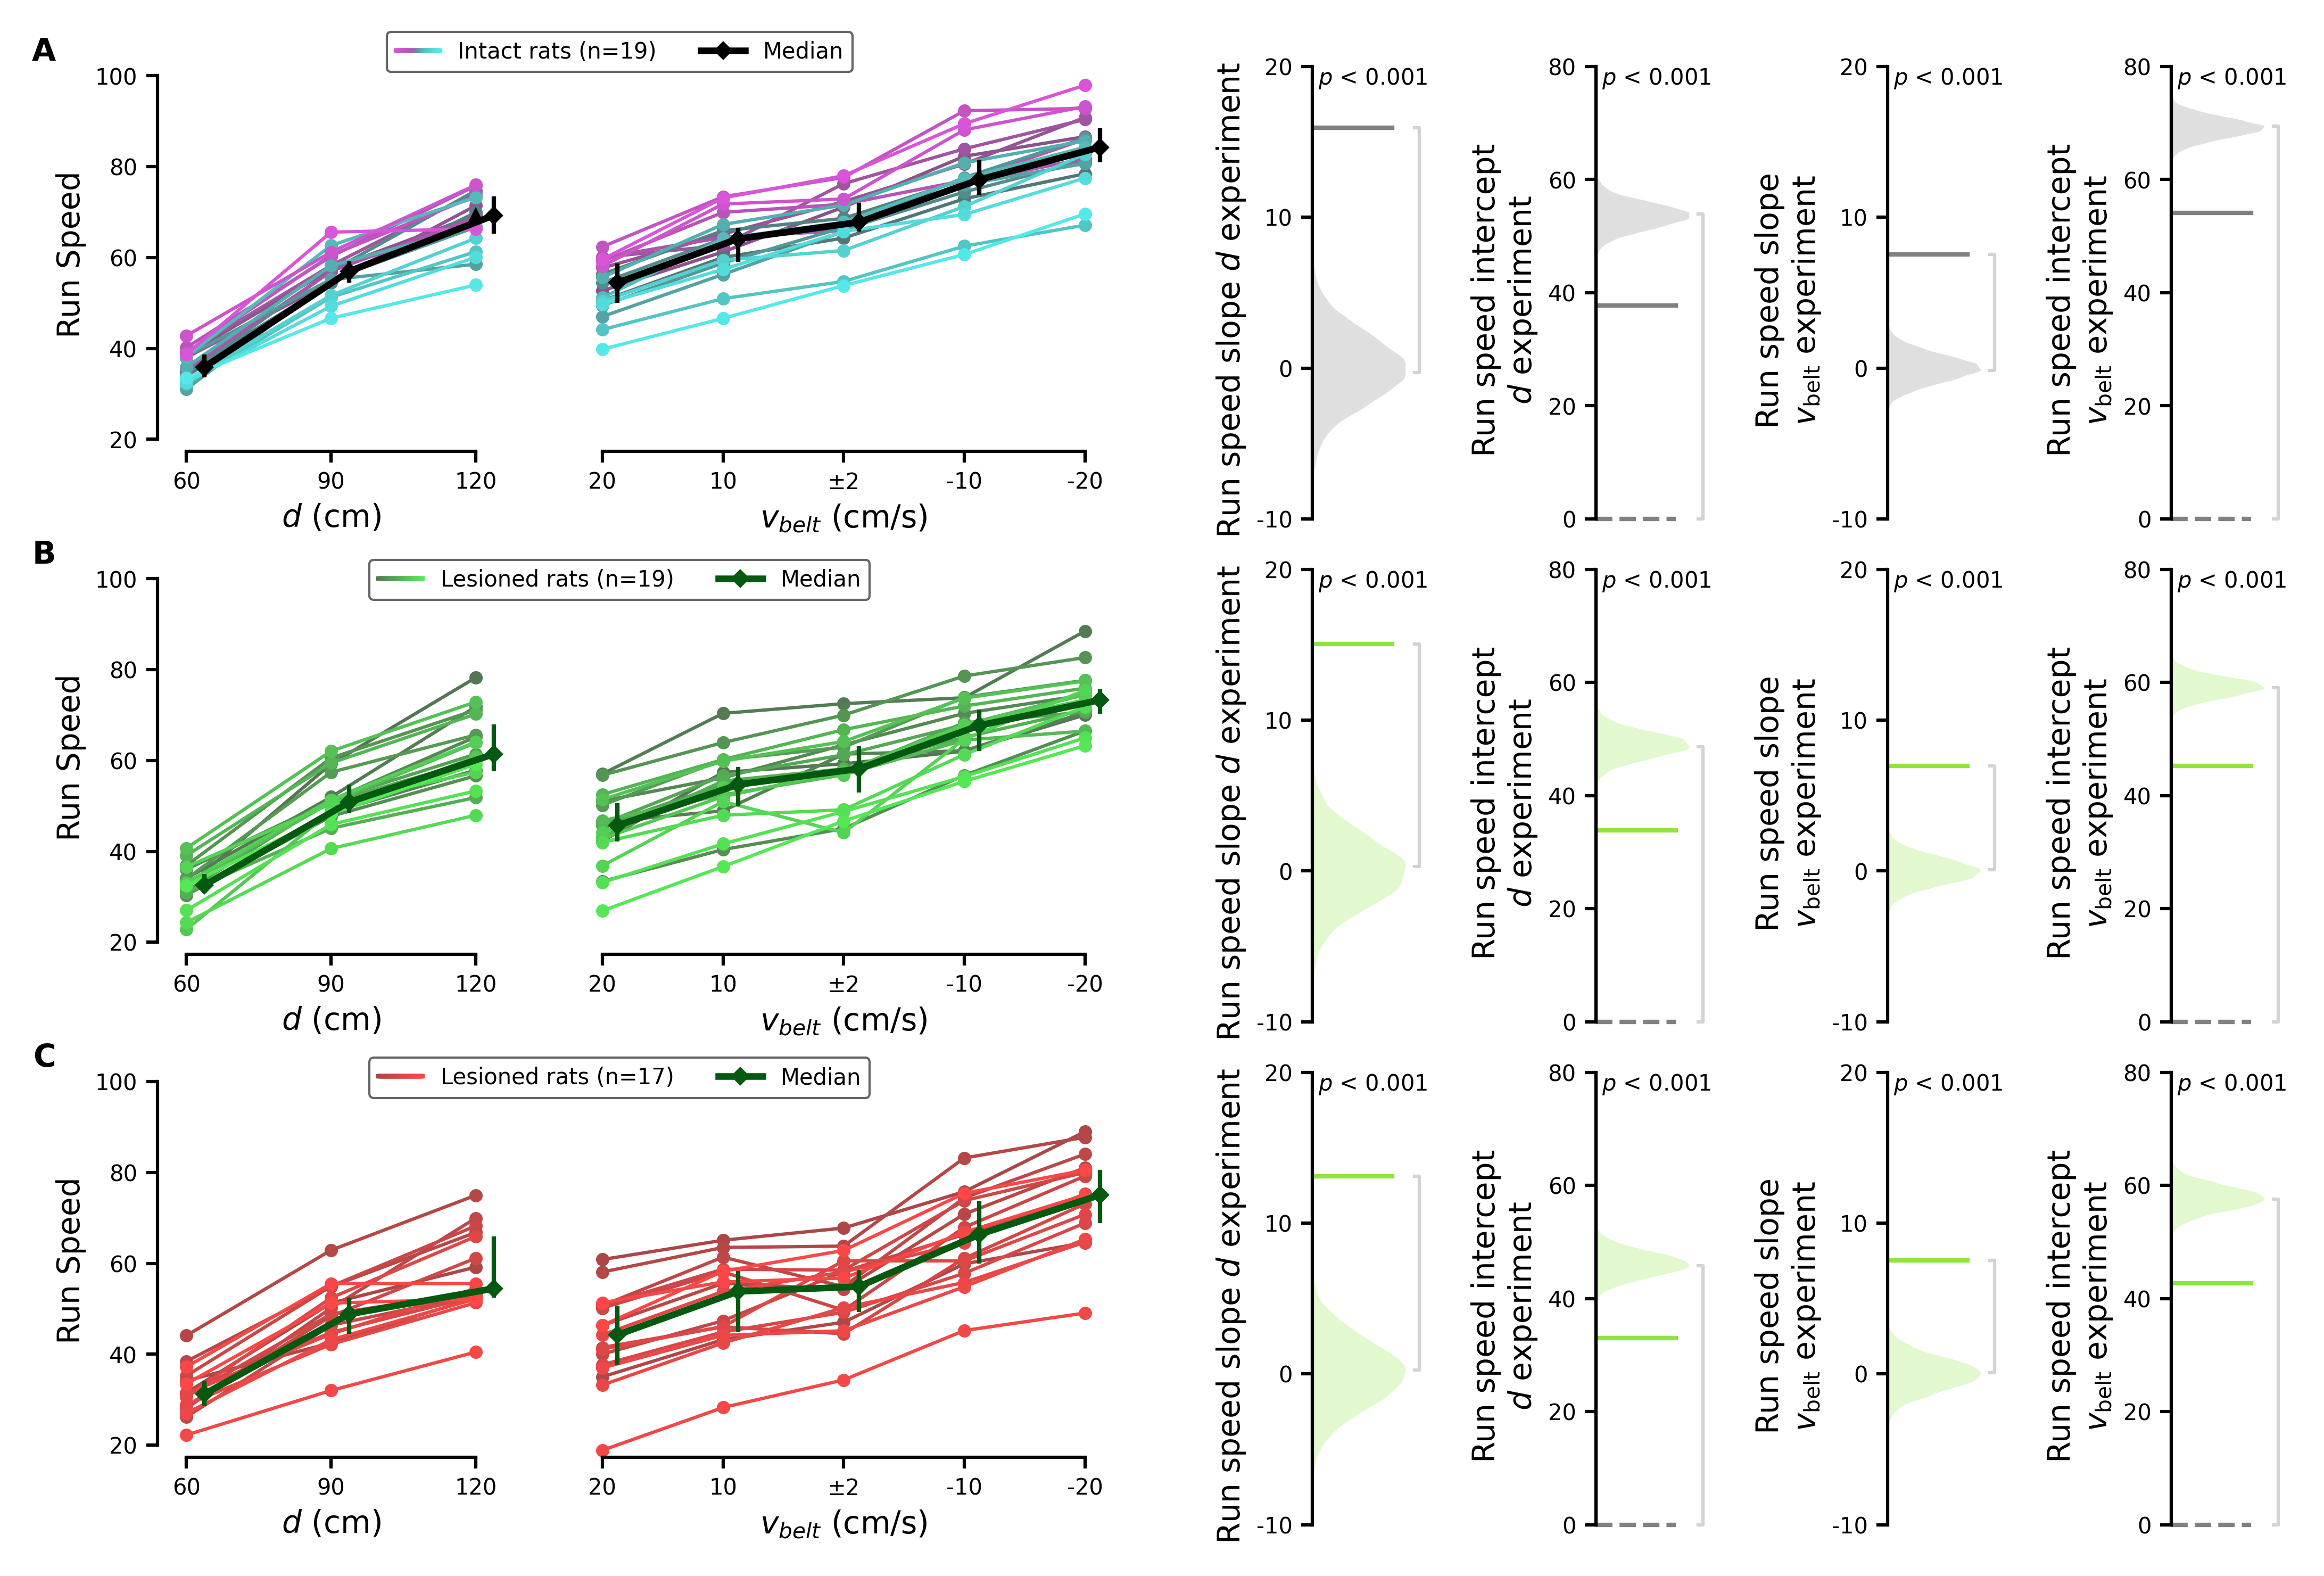

In [15]:
fig = plt.figure(figsize=(cm2inch(18), cm2inch(12)),
                 constrained_layout=True, facecolor='w', dpi=600)

gs0 = fig.add_gridspec(1, 3, width_ratios=[1, .05, 1])

left = gs0[0].subgridspec(3, 1)
left_row1 = left[0].subgridspec(1, 2, width_ratios=[3, 5])
ax_dist_intact = plt.subplot(left_row1[0])
ax_tm_intact = plt.subplot(left_row1[1])

left_row2 = left[1].subgridspec(1, 2, width_ratios=[3, 5])
ax_dist_ds = plt.subplot(left_row2[0])
ax_tm_ds = plt.subplot(left_row2[1])

left_row3 = left[2].subgridspec(1, 2, width_ratios=[3, 5])
ax_dist_vs = plt.subplot(left_row3[0])
ax_tm_vs = plt.subplot(left_row3[1])

right = gs0[2].subgridspec(3, 1)
right_row1 = right[0].subgridspec(1, 4)
ax_slope_dist_intact = plt.subplot(right_row1[0])
ax_intercept_dist_intact = plt.subplot(right_row1[1])
ax_slope_tm_intact = plt.subplot(right_row1[2])
ax_intercept_tm_intact = plt.subplot(right_row1[3])

right_row2 = right[1].subgridspec(1, 4)
ax_slope_dist_ds = plt.subplot(right_row2[0])
ax_intercept_dist_ds = plt.subplot(right_row2[1])
ax_slope_tm_ds = plt.subplot(right_row2[2])
ax_intercept_tm_ds = plt.subplot(right_row2[3])

right_row3 = right[2].subgridspec(1, 4)
ax_slope_dist_vs = plt.subplot(right_row3[0])
ax_intercept_dist_vs = plt.subplot(right_row3[1])
ax_slope_tm_vs = plt.subplot(right_row3[2])
ax_intercept_tm_vs = plt.subplot(right_row3[3])


_ = r'$d$'
__ = r'$v_{\mathrm{belt}}$'

plot_model_parameter(PLOT_PARAMS['run_speed'], rat_markers, dist_or_tm='dist', show_ex=True, ax=ax_dist_intact,
                     animal_list=intact_rats, show_xlabel=True, show_ylabel=True)

plot_model_parameter(PLOT_PARAMS['run_speed'], rat_markers, dist_or_tm='tm', show_ex=False, ax=ax_tm_intact,
                     animal_list=intact_rats, show_xlabel=True, show_ylabel=False, hide_y=True)

regression_permutation(run_speeds, dist_or_tm='dist', animal_list=intact_rats, color='gray',
                       varname_slope=f'Run speed slope {_} experiment',
                        varname_intercept=f'Run speed intercept\n{_} experiment',
                        ax_slope=ax_slope_dist_intact, yticks_slope=[-10, 0, 10, 20],
                        ax_intercept=ax_intercept_dist_intact, y_ticks_intercept=[0, 20, 40, 60, 80])

regression_permutation(run_speeds, dist_or_tm='tm', animal_list=intact_rats, color='gray',
                       varname_slope=f'Run speed slope\n{__} experiment',
                        varname_intercept=f'Run speed intercept\n{__} experiment',
                        ax_slope=ax_slope_tm_intact, yticks_slope=[-10, 0, 10, 20],
                        ax_intercept=ax_intercept_tm_intact, y_ticks_intercept=[0, 20, 40, 60, 80])



plot_model_parameter(PLOT_PARAMS['run_speed_lesion'], rat_markers,dist_or_tm='dist', show_ex=True, ax=ax_dist_ds,
                     animal_list=DSlesioned_rats, show_xlabel=True, show_ylabel=True, median_color='xkcd:deep green')

plot_model_parameter(PLOT_PARAMS['run_speed_lesion'], rat_markers,dist_or_tm='tm', show_ex=False, ax=ax_tm_ds,
                     animal_list=DSlesioned_rats, show_xlabel=True, show_ylabel=False, median_color='xkcd:deep green', hide_y=True)

regression_permutation(run_speeds_lesion, dist_or_tm='dist', animal_list=DSlesioned_rats, color='xkcd:kiwi green',
                        varname_slope=f'Run speed slope {_} experiment',
                        varname_intercept=f'Run speed intercept\n{_} experiment',
                        ax_slope=ax_slope_dist_ds, yticks_slope=[-10, 0, 10, 20],
                        ax_intercept=ax_intercept_dist_ds, y_ticks_intercept=[0, 20, 40, 60, 80])

regression_permutation(run_speeds_lesion, dist_or_tm='tm', animal_list=DSlesioned_rats, color='xkcd:kiwi green',
                       varname_slope=f'Run speed slope\n{__} experiment',
                        varname_intercept=f'Run speed intercept\n{__} experiment',
                        ax_slope=ax_slope_tm_ds, yticks_slope=[-10, 0, 10, 20],
                        ax_intercept=ax_intercept_tm_ds, y_ticks_intercept=[0, 20, 40, 60, 80])



plot_model_parameter(PLOT_PARAMS['run_speed_lesion'], rat_markers,dist_or_tm='dist', show_ex=True, ax=ax_dist_vs,
                     animal_list=VSlesioned_rats, show_xlabel=True, show_ylabel=True, median_color='xkcd:deep green')

plot_model_parameter(PLOT_PARAMS['run_speed_lesion'], rat_markers,dist_or_tm='tm', show_ex=False, ax=ax_tm_vs,
                     animal_list=VSlesioned_rats, show_xlabel=True, show_ylabel=False, median_color='xkcd:deep green', hide_y=True)

regression_permutation(run_speeds_lesion, dist_or_tm='dist', animal_list=VSlesioned_rats, color='xkcd:kiwi green',
                        varname_slope=f'Run speed slope {_} experiment',
                        varname_intercept=f'Run speed intercept\n{_} experiment',
                        ax_slope=ax_slope_dist_vs, yticks_slope=[-10, 0, 10, 20],
                        ax_intercept=ax_intercept_dist_vs, y_ticks_intercept=[0, 20, 40, 60, 80])

regression_permutation(run_speeds_lesion, dist_or_tm='tm', animal_list=VSlesioned_rats, color='xkcd:kiwi green',
                       varname_slope=f'Run speed slope\n{__} experiment',
                        varname_intercept=f'Run speed intercept\n{__} experiment',
                        ax_slope=ax_slope_tm_vs, yticks_slope=[-10, 0, 10, 20],
                        ax_intercept=ax_intercept_tm_vs, y_ticks_intercept=[0, 20, 40, 60, 80])



legend_intact = fig.add_axes([.25, .99, .01, .01])
legend_ds = fig.add_axes([.25, .64, .01, .01])
legend_vs = fig.add_axes([.25, .31, .01, .01])
dummy_legend_intact(ax=legend_intact)
dummy_legend_lesion(ax=legend_ds)
dummy_legend_lesion_vs(ax=legend_vs)

add_all_letters([ax_dist_intact, ax_dist_ds, ax_dist_vs], ["A", "B", "C"])

plt.savefig("./Figures_paper/Figure_SXXXX.pdf", facecolor='w', 
        edgecolor='none', bbox_inches='tight', format="pdf", dpi=600)
plt.savefig("./Figures_paper/Figure_SXXXX.svg", facecolor='w', 
        edgecolor='none', bbox_inches='tight', format="svg", dpi=600)